# Componente 1: Ingeniería de Datos y Representación de Secuencias
En este notebook desarrollaremos el primer componente del Proyecto 2: Detección de Lavado de Dinero en Remesas.

## Decisiones tomadas:
1. **Subconjunto de Datos:** Se seleccionó `HI-Small_Trans.csv` (~475MB) del dataset de IBM. **Justificación:** Los datasets más grandes superan los límites de memoria locales y de Colab gratuito. Este subset contiene ~5 millones de transacciones con un alto ratio de transacciones ilícitas (HI = High Illicit), asegurando suficientes casos positivos (3,376 remitentes sospechosos) para que el modelo aprenda patrones de lavado sin colapsar la RAM.
2. **Construcción de Secuencias:** Las transacciones se agrupan por `SenderAccount` y se ordenan por `Timestamp`.
3. **Manejo de Desbalance y Partición:** La partición se hará a nivel de *remitentes* para evitar la filtración de datos (Data Leakage) entre secuencias de la misma cuenta.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid")

## 1. Carga y Exploración Inicial de Datos

In [3]:
file_path = "data/raw/archive ibm/HI-Small_Trans.csv"

# Definir las columnas a usar para ahorrar memoria
cols = [0, 2, 5, 9, 10]
col_names = ["Timestamp", "SenderAccount", "Amount", "PaymentFormat", "IsLaundering"]

print("Cargando dataset...")
df = pd.read_csv(file_path, usecols=cols, names=col_names, header=0)

# Convertir Timestamp a datetime
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
print(f"Total de transacciones: {len(df):,}")
display(df.head())

Cargando dataset...
Total de transacciones: 5,078,345


,Timestamp,SenderAccount,Amount,PaymentFormat,IsLaundering
0,2022-09-01 00:20:00,8000EBD30,3697.34,Reinvestment,0
1,2022-09-01 00:20:00,8000F4580,0.01,Cheque,0
2,2022-09-01 00:00:00,8000F4670,14675.57,Reinvestment,0
3,2022-09-01 00:02:00,8000F5030,2806.97,Reinvestment,0
4,2022-09-01 00:06:00,8000F5200,36682.97,Reinvestment,0


## 2. Ingeniería de Features (Características)
Para que las transacciones aporten valor temporal, extraeremos el día de la semana y la hora del día. En lavado de dinero, las remesas en horas atípicas son fuertes señales de alerta.

In [4]:
# Extraer features temporales
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

# Normalizar el monto con RobustScaler para reducir la influencia de valores extremos (outliers)
scaler = RobustScaler()
df["Amount_Scaled"] = scaler.fit_transform(df[["Amount"]])

# One-Hot Encoding para los formatos de pago
df = pd.get_dummies(df, columns=["PaymentFormat"], drop_first=False)

display(df.head())

,Timestamp,SenderAccount,Amount,IsLaundering,Hour,DayOfWeek,Amount_Scaled,PaymentFormat_ACH,PaymentFormat_Bitcoin,PaymentFormat_Cash,PaymentFormat_Cheque,PaymentFormat_Credit Card,PaymentFormat_Reinvestment,PaymentFormat_Wire
0,2022-09-01 00:20:00,8000EBD30,3697.34,0,0,3,0.187976,False,False,False,False,False,True,False
1,2022-09-01 00:20:00,8000F4580,0.01,0,0,3,-0.116009,False,False,False,True,False,False,False
2,2022-09-01 00:00:00,8000F4670,14675.57,0,0,3,1.090575,False,False,False,False,False,True,False
3,2022-09-01 00:02:00,8000F5030,2806.97,0,0,3,0.114772,False,False,False,False,False,True,False
4,2022-09-01 00:06:00,8000F5200,36682.97,0,0,3,2.899963,False,False,False,False,False,True,False


## 3. Construcción de Secuencias por Remitente
Vamos a agrupar los datos por `SenderAccount`. Una cuenta se considera **sospechosa** si al menos una de sus transacciones es fraude.

In [5]:
print("Agrupando por remitente...")

# Encontrar si un remitente es sospechoso
sender_labels = df.groupby("SenderAccount")["IsLaundering"].max().rename("IsSuspicious")

# Contar cuántas transacciones tiene cada remitente
seq_lengths = df.groupby("SenderAccount").size().rename("SeqLength")

# Unir la metadata de los remitentes
sender_meta = pd.concat([sender_labels, seq_lengths], axis=1)

print(f"Total de remitentes: {len(sender_meta):,}")
print(f"Remitentes sospechosos (positivos): {sender_meta['IsSuspicious'].sum():,}")
print(f"Remitentes normales (negativos): {len(sender_meta) - sender_meta['IsSuspicious'].sum():,}")

Agrupando por remitente...
Total de remitentes: 496,995
Remitentes sospechosos (positivos): 3,376
Remitentes normales (negativos): 493,619


### Visualización Obligatoria: Distribución y Desbalance
Como solicita la rúbrica, vamos a visualizar la distribución de las longitudes de las secuencias y la proporción de casos positivos vs negativos.

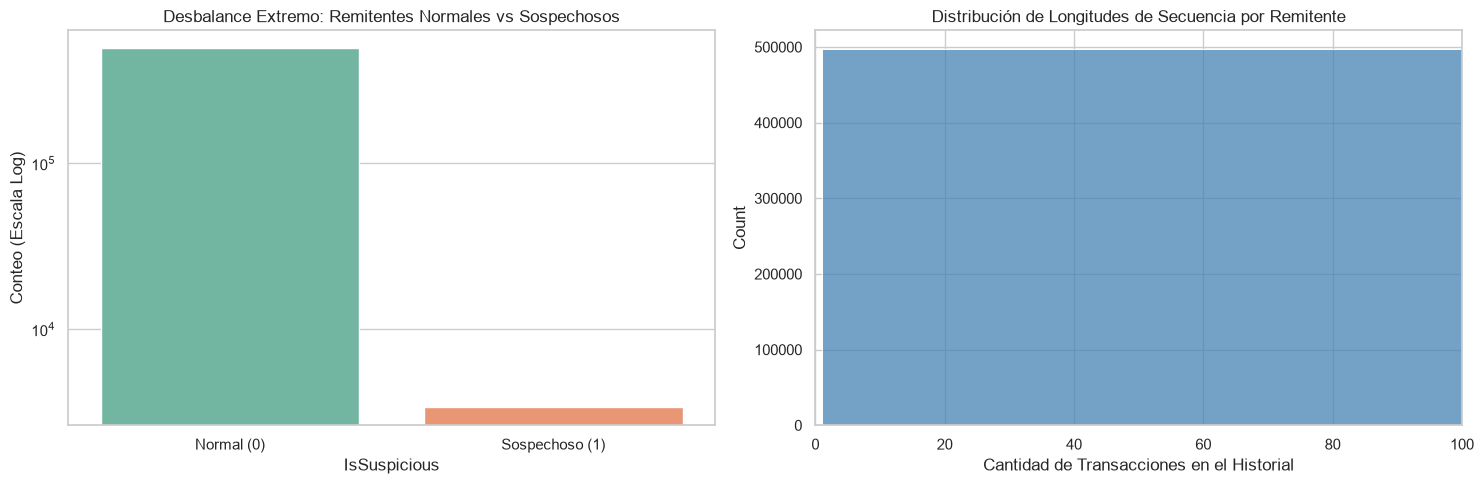

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfica 1: Proporción de Casos
sns.countplot(data=sender_meta, x="IsSuspicious", ax=axes[0], palette="Set2")
axes[0].set_title("Desbalance Extremo: Remitentes Normales vs Sospechosos")
axes[0].set_yscale("log") # Escala logarítmica para poder ver la barra de sospechosos
axes[0].set_ylabel("Conteo (Escala Log)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Normal (0)", "Sospechoso (1)"])

# Gráfica 2: Distribución de Longitudes de Secuencia
sns.histplot(data=sender_meta, x="SeqLength", bins=50, ax=axes[1], color="steelblue")
axes[1].set_title("Distribución de Longitudes de Secuencia por Remitente")
axes[1].set_xlim(0, 100) # Recortamos la vista para omitir colas muy largas
axes[1].set_xlabel("Cantidad de Transacciones en el Historial")

plt.tight_layout()
plt.show()

## 4. Partición del Dataset (Train/Val/Test) evitando Filtración de Datos (Data Leakage)
La partición se realiza **a nivel de remitentes** (cuentas) y no a nivel de transacciones. Esto asegura que el historial completo de un usuario esté solo en uno de los conjuntos.

Para la **Etapa A (Aprendizaje de Normalidad)**, extraeremos únicamente usuarios normales del set de entrenamiento.